# Project Final Report

### Due: Midnight on April 27th (2-hour grace period) — 50 points  

### No late submissions will be accepted.


## Overview

Your final submission consists of **two components**:


### 1. Team Final Report Notebook [50 pts]

Complete all sections of this notebook to document your final decisions, results, and broader context.

You will write a **technical report** following standard conventions. Useful references include:
- [CMU guide to structure](https://www.stat.cmu.edu/~brian/701/notes/paper-structure.pdf)
- [Data science report example](https://www.projectpro.io/article/data-science-project-report/620)
- The Checklist in this week’s Blackboard Lesson (aligned with HOML)

Your audience is **technically literate but unfamiliar with your work**—for example, your manager or other data scientists. Your report should be clear, precise, and well-organized, combining explanation, visualizations, and interpretation.

This Final Report is distinct from Milestone 2:

- **Milestone 2** serves as a repository of your working code and experiments  
- **This Final Report** presents a clear, structured summary of your project for a professional audience  

> **Important:**
> - Do **not** assume that readers of this report are familiar with Milestone 2. Your report should stand on its own.
> - Do not include full code or code cells in this notebook. All code was submitted in Milestone 2. This report should focus on explanation, results, and interpretation.
> - **Do not add, delete, or move cells in this notebook.** Each answer must be written entirely within its assigned Markdown cell.
> - All answers should be inserted directly under the appropriate `Answer:` prompt. Delete the sentence "Replace this sentence with your answer" and replace it with your response.
> - You may use any appropriate Markdown formatting (paragraphs, lists, tables, inserted graphics, LaTeX, etc.).
> - Submit this notebook as a group via your team leader’s Gradescope account.


### 2. Individual Assessment [0 points]

Each team member must **individually** complete the Final Project Individual Assessment Form (similar to Milestone 1), sign it, and upload it via their own Gradescope account.

**Due:** May 5th @ 2:00 AM



## Submission Checklist

- Final Report Notebook — submitted by team leader  
- Individual Assessment Form — submitted by each team member  



## 1. Executive Summary [4 pts]

Write a 300–400 word executive summary for a **non-technical audience**, such as business stakeholders in a real estate company.

Your summary should explain:
- the objective of the project
- key insights about the data
- the most important findings, including a plain-language description of model performance
- a clear recommendation or takeaway

Avoid technical detail and jargon. Focus on what matters and why.

**1.1 Answer:**  
# Executive Summary: Zillow Assessed Tax Property Value Prediction

**Project Objective:**

Our team was tasked to build a data-driven tool that estimates the assessed value of residential properties using the provided dataset. The goal of this project was to improve Zillow’s pricing accuracy, support data-driven decision making, and help provide more reliable home value estimates to customers.

**Data Analysis:**

These data included features such as square footage, number of bedrooms and bathrooms, lot size, location, pool and garage features and more. The data needed significant pre-processing due to many empty fields (some with over 95% incomplete values), removal of internal identifiers lacking predictive value, and handling of extreme outliers. After analyzing the shape and content of the data, we were left with a reliable and well-structured dataset ready for supervised modeling.Exploratory data analysis revealed that larger homes are indicative of higher property value, bathroom count is a strong price signal, and the target property values were highly right skewed. Specifically, a relatively small number of higher-end properties were pulling the average upward significantly.

**Model Performance:**

We tested three model approaches; a more straightforward Lasso Regression (a linear method), a rule-based Decision Tree Regression, and Gradient Boosting, a model that builds on its own errors to improve predictions. The best performing model was Gradient Boosting, which predicted property values with an average error of ~$196,000 on property data it had not seen before. Despite this large value, this error represents strong performance given the context that the property values in this dataset span a wide distribution. The linear model was consistently underperforming, despite attempting to tune parameters as we went, and the Decision Tree model seemed to be memorizing training data and did not perform well on unseen data.

**Recommendation:**

We recommend using a Gradient Boosting model as the foundation for an automated valuation tool. It has proven to reliably capture complex, non-linear relationships between home features and price, and strikes the best balance between accuracy and consistency, which may not be fully captured by simpler models. The next priority should be enriching the input data with neighborhood-specific features, such as proximity to schools, walkability, and comparable sales, which will strengthen the predictive value beyond the current available features.


## 2. Introduction [3 pts]

Introduce the topic, context, and goals of your project.

You may imagine that this project was completed for a **real estate company with a small in-house data science team**.

Include all of the following:

- Clearly introduce the topic and context of your project
- Describe the problem you are addressing (the problem statement) and the overall motivation for solving it
- Clearly state the objectives and goals of your analysis (as different from the motivation)

**2.1 Answer:**  
One of the largest challenges in real estate is accurately pricing residential properties. Inaccurate predictions can result in mispriced listings, lost revenue, and poor customer trust. Our team set out to address this by building scalable, data-driven solutions that reduce dependence on manual appraisals and deliver more consistent valuations across different property types.

Our objective was to build a supervised regression model that predicts a property's assessed tax value from available home characteristics, such as square footage, bedroom and bathroom count, and location, with measurable accuracy on data the model had not previously seen.


## 3. Data Description [3 pts]

Describe the dataset used in your analysis.

Include:
- the source of the dataset
- the number of observations (samples) and features
- the types of variables
- the target variable
- missing values or other important issues in the raw data

**3.1 Answer:**  
This dataset provided is a subset version of a Zillow housing dataset used in the Zillow Million Dollar Prize competition on Kaggle in 2017. The dataset contains 77613 entries and 55 columns, consisting of float, integer, and object datatypes. The target variable was defined to be the assessed tax value [‘taxvaluedollarcnt’].

The dataset contained a significant number of missing values across many features. Several columns, such as ‘basementsqft’, ‘architecturalstyletypeid’, and ‘buildingclasstypeid’ had over 95% missing data and were dropped entirely as they did not provide predictive value. Overall, the dataset contained many meaningful predictors, such as information on square footage, bedroom / bathroom counts, and location based features that can support supervised regression modelling.

## 4. Methodology (What you did, and why) [20 pts]

Focus on the **process and your reasoning**, not the results.

Note: Each subsection (e.g., 4.1, 4.2, etc.) must be answered in its own Markdown cell.  Each subsection is worth 5 points.

### 4.1 Analytical Framework

Describe your overall approach.

Include:
- your overall framework
- use of validation curves
- choice of MAE or RMSE (as appropriate) as the primary error metric

**4.1 Answer:**  
Our approach was to test three different supervised regression models and ultimately decide which model performed best on the data and provided the best insights. Following a standard workflow, starting with preprocessing the data to remove null values and extreme outliers. Then, we performed an 80/20 train/test split, holding out the test set until final evaluation to prevent data leakage. Each model was evaluated based on its performance on the training data, using repeated k-fold cross validation (CV) with 5 folds and 5 repeats to provide stable performance estimates and help to detect overfitting by comparison training mean absolute error (MAE) against CV MAE).

MAE was chosen as the primary error metric due to the right-skewed distribution of the target variable. Unlike RMSE, which squares each error and disproportionately inflates the result due to extreme outliers, MAE treats errors equally without regard to magnitude. This makes it a more robust metric for comparing model performance.


### 4.2 Data Cleaning and Preprocessing

Describe how you prepared the data.

Include:
- issues in the raw data
- handling of missing values, outliers, inconsistencies
- key decisions and why
- what worked and what did not work

**4.2 Answer:**  
The raw dataset presented several issues that required attention before we began modeling. The key issues involved features with a high number of missing values, identifier columns with no predictive value, features that were mostly constant, and significant outliers in both the target variable and predictor features.

We filtered out identifier features, such as ‘parcelid’ and ‘regionidzip’, as they possessed no predictive value toward the model. Features with little variation, such as ‘poolcnt’ and ‘decktypeid’, were removed as well. Categorical flags, such as ‘hashottuborspa’ and ‘fireplaceflag’, were found to be largely constant or sparse and unlikely to improve model performance.

Additionally, features with more than 90% of missing values were dropped as they contained insufficient information to impute or extract meaningful patterns from. This threshold was chosen as it meaningfully retained useful features, but removed those that would introduce unwelcome noise or require excessive imputation. Extreme outliers were filtered out to reduce the influence of large values.

Missing values were imputed using the median, as this is robust to outliers and representative of the central tendency of a skewed distribution. Categorical features were imputed using mode imputation where missing values were likely random, and by introducing an ‘Unknown’ category for system types like heating and air conditioning where missing values were likely to represent meaningful absence. High-cardinality categorical columns were dropped, and remaining categorical features were one-hot encoded before modeling.

Overall, the 90% missing value threshold and median imputation retained effective signal while keeping the preprocessing straightforward. Retaining features with a high number of missing values and imputation was considered but rejected, as these values would not accurately represent real trends in the data.


### 4.3 Feature Engineering

Describe your feature engineering.

Include:
- transformations or new features
- why you created them
- which were useful or not useful
- what worked and what did not work

**4.3 Answer:**  
The team’s feature engineering focused on creating transformations that captured the nonlinear relationships in housing Zillow’s housing data. The new features created include log-transformed square footage (log_sqft) to reduce skewness and model diminishing returns, squared square footage (sqft_squared) to capture nonlinear growth effects, bathroom-to-bedroom ratio (bath_bed_ratio) to reflect home layout efficiency, and house age (house_age) to account for deprecation and structural differences over time. These features were motivated by earlier correlation analysis and F-score results, where size-related variables showed strong relationships with the target variable.

The effectiveness of these features varied across models. For example, in Lasso Regression, feature engineering significantly improved performance, reducing CV MAE from 242,264 to 234,831. This suggests that linear models benefited from transformations that make relationships more linear and interpretable. Features such as log_sqft and sqft_squared were particularly useful, as they helped capture patterns that the base linear model could not represent. These engineered features were also consistently selected during feature selection, reinforcing their importance.

However, for tree-based models (Decision Tree and Gradient Boosting), the engineered features were less beneficial. Performance either remained similar or slightly worsened, indicating that these models already capture nonlinear relationships inherently. In some cases, the added transformations introduced redundancy or noise. To summarize, feature engineering was most effective for linear models, while having a more limited impact on tree-based models.


### 4.4 Model Selection

Describe how you selected your model.

Include:
- models you tried and why
- how you evaluated generalization
- hyperparameter tuning
- how you chose the final model

**4.4 Answer:**  
The team evaluated three models Lasso Regression serving as a regularized linear model, Decision Tree Regression as a simple nonlinear model, and Gradient Boosting Trees as a more advanced ensemble method. Model performance was evaluated using repeated cross-validation (5 folds, 5 repeats) with Mean Absolute Error (MAE) as the primary metric, along with standard deviation to assess model stability and generalization.

The performance of these models varied significantly. Gradient Boosting Trees consistently performed the best, achieving the lowest CV MAE and low standard deviation. After hyperparameter tuning, the model achieved a final CV MAE of \$189,297.63 and test MAE of \$195,927.58, outperforming both Lasso and Decision Tree models by a substantial margin. The Decision Tree model showed notable improvement after tuning, reducing its CV MAE to approximately 209,968, but still lagged behind Gradient Boosting. Lasso also improved with feature engineering and feature selection, but remained the weakest overall performer in terms of predictive accuracy.

Generalization was assessed through both cross-validation performance and comparison between training and test MAE. Gradient Boosting showed a gap between training MAE (\~157k) and CV/test (~189k-196k), indicating some overfitting, but it still maintained the best overall performance. A key trade-off in model selection was interpretability versus performance. While Lasso provided greater interpretability, Gradient Boosting delivered significantly better predictive accuracy. To conclude, Gradient boosting was selected as the final model due to its superior performance, despite its higher complexity and computational cost.   


## 5. Results and Evaluation (What you found, and how well it worked) [16 pts]

Focus on **results, evidence, and interpretation**.

Note: Each subsection (e.g., 5.1, 5.2, etc.) must be answered in its own Markdown cell.

### 5.1 Model Performance (6 points)

Briefly interpret what your metrics mean in practical terms.

Include:
- key metrics (e.g., RMSE, $R^2$)
- comparison across models
- comparison of training vs validation/test performance

**5.1 Answer:**  
The performance of the models was evaluated using Mean Absolute Error (MAE) across cross-validation folds. MAE represents the average absolute difference between predicted and actual values, meaning it reflects the typical prediction error in dollar terms for median earnings.

The Final Tuned Lasso model produced a mean CV MAE of 233,626.53 USD with a standard deviation of 2,915.66 USD, indicating relatively stable but less accurate predictions compared to the other models. This suggests that the linear model is consistent but struggles to capture more complex relationships in the data.

The Tuned Decision Tree model improved performance, achieving a mean CV MAE of 209,967.98 USD with a standard deviation of 2,781.64 USD. This reduction in MAE indicates better predictive accuracy and highlights the importance of nonlinear relationships and feature interactions.

The Gradient Boosting model performed the best, with a final CV MAE of 189,297.63 USD and a standard deviation of 2,378.49 USD, representing the lowest prediction error among all models. This demonstrates that ensemble methods are more effective at capturing complex patterns in the data.

When comparing training vs. test performance for the selected Gradient Boosting model  we saw that training MAE was 157,135.80 USD while test MAE was 195,927.58 USD.

The training error is notably lower than the test error, indicating some degree of overfitting, as the model performs better on data it has already seen. However, the gap is not excessively large, suggesting that the model still generalizes reasonably well to unseen data.


### 5.2 Visualizations (5 points)

Graphics should be made as screenshots and dragged into the Markdown cell. Do NOT add code cells to create graphics. Each visualization must be clearly labeled and explained in the text.

Include:
- relevant plots with titles and labels
- explanation of what each plot shows
- why each visualization matters

**5.2 Answer:**  

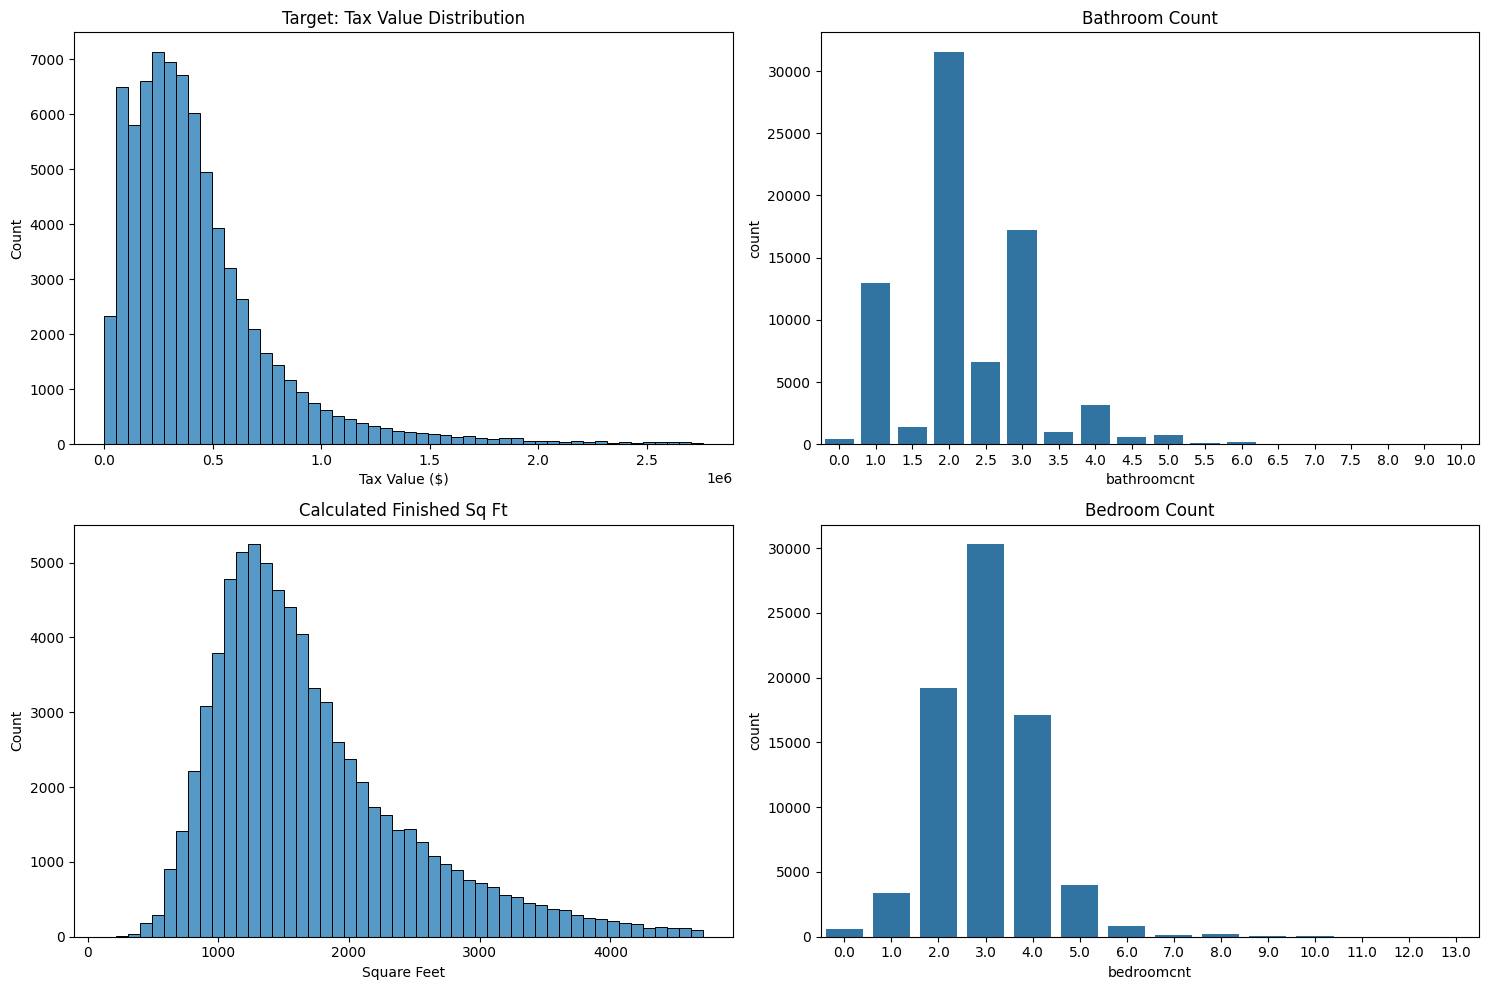

**Figure 1:** Distribution of Key Features and Target Variable

This set of histograms shows the distributions of the target variable (tax value) and several important features, including bathroom count, bedroom count, and calculated finished square footage.

The target variable (tax value) displays a strong right-skewed distribution, with most properties clustered at lower values with a tail extending toward very high values. This indicates the presence of high-value outliers, which can make prediction more difficult and contribute to larger errors in the model.

The calculated finished square footage also shows a right-skewed distribution, though less extreme. Most homes fall within a moderate size range, but there are some significantly larger properties. This aligns with the feature importance results, where square footage-related variables were among the most influential predictors.

The bathroom count and bedroom count distributions are discrete variables and are concentrated around lower, common values like 2 to 4 bedrooms and 2 to 3 bathrooms. This reflects typical housing patterns and suggests these variables provide useful but less varied information compared to continuous features like square footage.

This visualization is important because it highlights the skew in the target variable and shows the presence of outliers within the data. It also shows transformations to be important to the data in order to not bias the model.

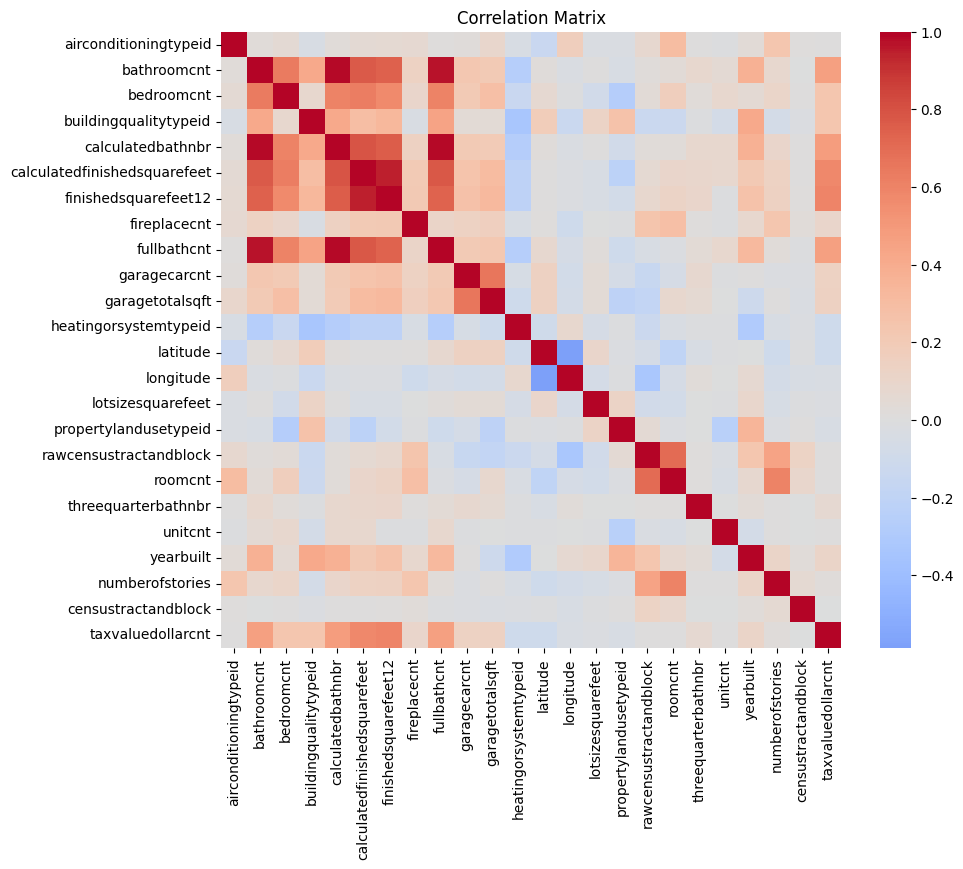

**Figure 2** Correlation Matrix of Features and Target Variable
This heatmap displays the pairwise correlations between all features and the target variable of tax value. Warmer colors (red) indicate stronger positive correlations, while cooler colors (blue) indicate negative correlations.

This visualization shows a few important things about the relationships between these variables and the target value. First, features related to property size, such as “calculatedfinishedsquarefootage” and “finishedsquarefeet12”, show strong positive correlations with the target variable. This indicates that larger homes tend to have higher tax values, as expected. Second, variables related to bathrooms and bedrooms like “bathroomcnt” and “bedroomcnt” are also moderately positively correlated with the target, suggesting that larger homes with more of these rooms tend to be higher in value. Finally, geographic features such as latitude and longitude show relatively weaker correlations with the target, indicating that while location matters, its effect may be more nuanced and case by case than an end all be all.

This visualization is important because it identifies key drivers of the target variable, reinforcing findings from the feature importance plot, it highlights highly correlated features and helps explain why tree-based models performed better, as they handle these relationships in a better way.

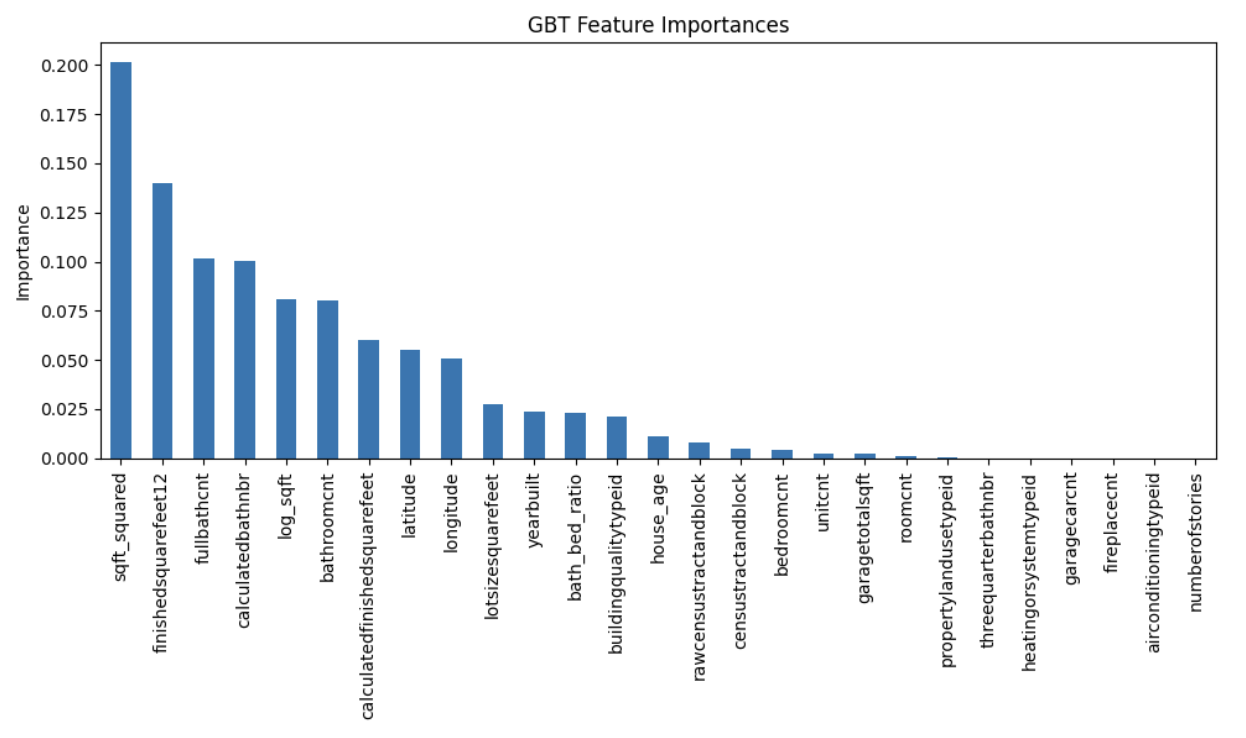

**Figure 3:** Gradient Boosting Feature Importances

This plot shows the relative importance of each feature used in the final Gradient Boosting model. Feature importance represents how much each variable contributes to reducing prediction error across all trees in the ensemble.

From the visualization, “sqft_squared” is the most important feature by a significant margin, followed by “finishedsquarefeet12,” “fullbathcnt,” and “calculatedbathnbr.” This indicates that property size and bathroom-related features are the strongest drivers of median home value predictions in the dataset.

Additionally, features such as log-transformed square footage, “log_sqft”, and calculated finished square footage also rank highly, reinforcing the importance of size-related variables. Geographic features like latitude and longitude have moderate importance, suggesting that location plays a role but is less influential than property characteristics.

This visualization is important for a couple reasons. First, it helps identify which features are most influential in predicting the target variable. Second, it confirms that engineered features, like “sqft_squared” are meaningful and improve predictive performance.


### 5.3 Error Analysis (5 points)

Include:
- patterns in residuals or prediction errors
- overprediction or underprediction
- outliers or unusual observations
- anything surprising or worth improving

**5.3 Answer:**  
The mean residual is 10,390, and the median residual is 2,639, both of which are relatively low compared to the scale of the target variable. This indicates that the model does not exhibit strong bias.

The number of underpredictions, 7,857, and overpredictions, 7,659, are very similar, further confirming that the model is generally well-balanced and does not consistently favor one type of error, but very minimally more often underpredicts.

The maximum absolute error, 40.8 million USD, is very large, especially in relation to the MAE, indicating the presence of significant outliers or extreme prediction errors. This suggests that the model struggles with unusually high property values or uncommon feature combinations.

Combined with the earlier observation that training MAE (157,135.80 USD) is lower than test MAE (195,927.58 USD), there is evidence of slight overfitting, although the model still generalizes well overall.

Future improvements could be made to the model to better handle outliers and extreme home values.


## 6. Conclusion [4 pts]

Summarize your findings and implications.

Include all the following:

- Clearly state your main findings and how they address your original objectives
- Highlight any business or practical implications of your findings
- Discuss the limitations and constraints of your analysis clearly and transparently
- Suggest potential improvements or future directions
- Conclude with a final recommendation addressing the business objective

**6.1 Answer:**  
This project successfully achieved its objective of building a supervised regression model capable of predicting residential property assessed tax values from available home features. Across all three models tested, Gradient Boosting emerged as the best performing model with a test MAE of 196,000 USD and low variance. This model outperformed Lasso Regression and Decision Tree models by a significant margin. The most influential features were found to be square footage (especially the log-transformed and squared variants), bedroom to bathroom ratio, and house age which can capture property depreciation and structural differences over time that size metrics alone cannot capture.

The dataset required heavy preprocessing due to a high volume of missing values and extreme outliers. Residual analysis confirmed that despite the model being well-balanced overall, it struggled with extreme high-value properties due to the target variable’s strong right-skew.

To improve this model, we suggest moving forward with additional hyperparameter tuning, further feature engineering, and testing more complex ensemble methods with high predictive power, such as Random Forest, to provide a more comparable performance against Gradient Boosting. Incorporating neighborhood-level context, such as proximity to schools, transit, and nearby properties, would strengthen the predictions beyond what property characteristics alone can provide.

Overall, Gradient Boosting offers a strong foundation for an automated valuation tool but further investment in model complexity and data enrichment will allow for more accurate predictions.

